![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [ ]:
!sudo apt-get install libgomp1
!sudo apt-get install libxft2
!sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

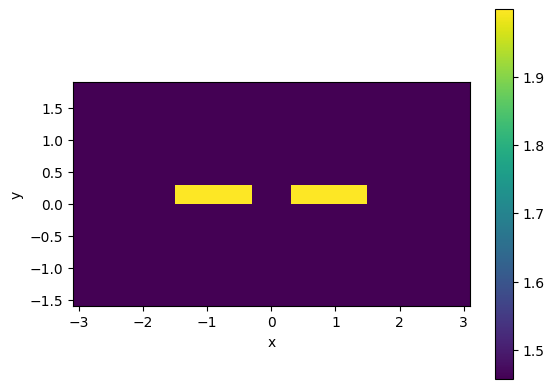

In [4]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [5]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

14:55:51 CET WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-03-12 14:55:51.735 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [6]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [7]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

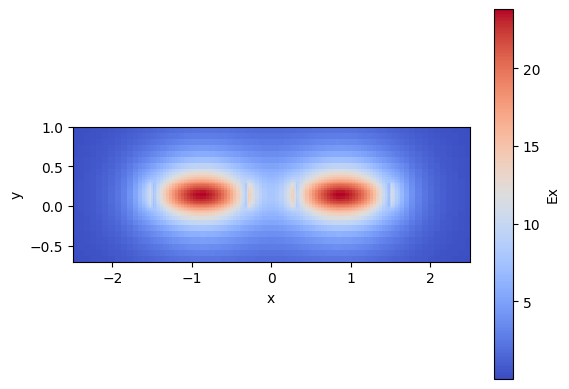

In [8]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

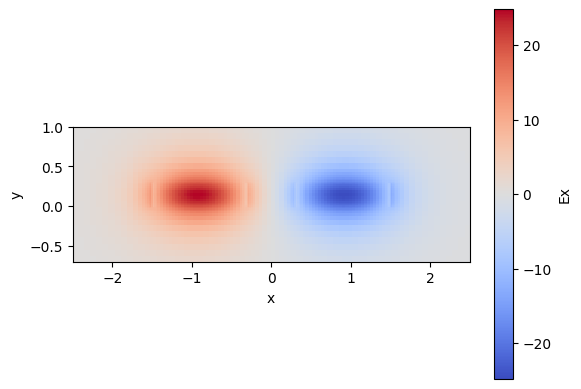

In [9]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

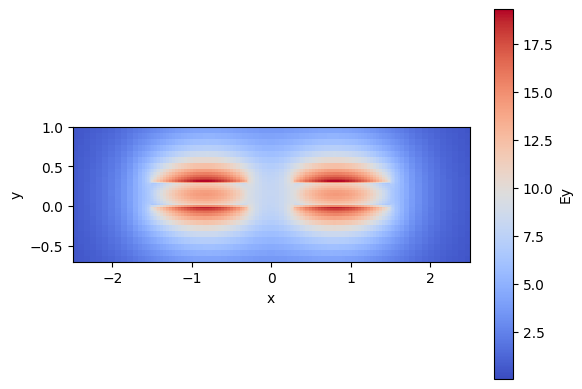

In [10]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

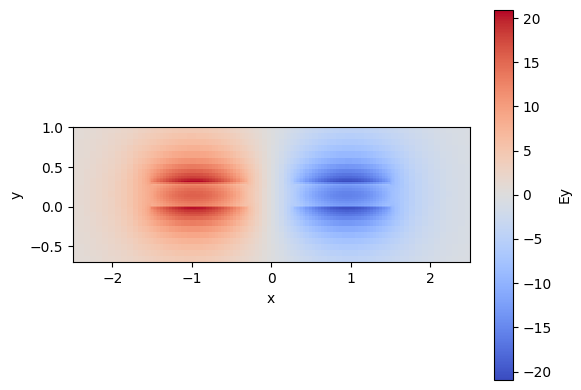

In [11]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [12]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536699492
52.26022367744298


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [13]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

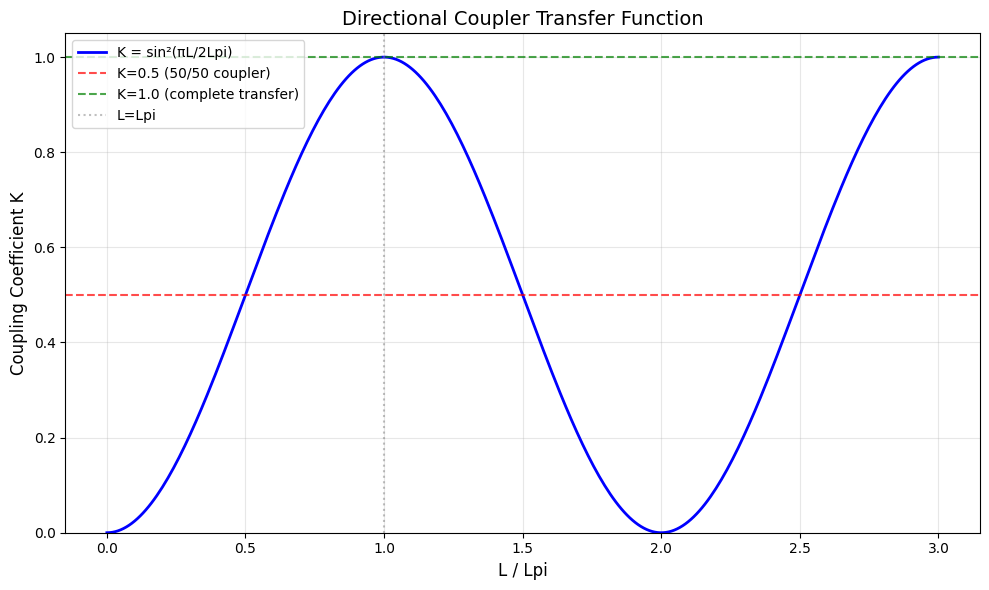

Coupling Coefficient Analysis:
At L=Lpi/2: K = 0.5000 (50% power transfer)
At L=Lpi: K = 1.0000 (complete power transfer)
Distance for complete energy transfer: L = Lpi ≈ 93.84 µm
Distance for 50% power splitting: L = Lpi/2 ≈ 46.92 µm


In [14]:
# LO.2 Analysis: Plot transfer function K vs L/Lpi
L_pi_TE = 93.83767536699492  # From previous calculation

# Create array of L/Lpi ratios
L_over_Lpi = np.linspace(0, 3, 300)

# Calculate coupling coefficient K = sin^2(pi * L / (2*Lpi))
K = np.sin(np.pi * L_over_Lpi / 2)**2

plt.figure(figsize=(10, 6))
plt.plot(L_over_Lpi, K, 'b-', linewidth=2, label='K = sin²(πL/2Lpi)')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='K=0.5 (50/50 coupler)')
plt.axhline(y=1.0, color='g', linestyle='--', alpha=0.7, label='K=1.0 (complete transfer)')
plt.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5, label='L=Lpi')
plt.xlabel('L / Lpi', fontsize=12)
plt.ylabel('Coupling Coefficient K', fontsize=12)
plt.title('Directional Coupler Transfer Function', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

print("Coupling Coefficient Analysis:")
print(f"At L=Lpi/2: K = {np.sin(np.pi/4)**2:.4f} (50% power transfer)")
print(f"At L=Lpi: K = {np.sin(np.pi/2)**2:.4f} (complete power transfer)")
print(f"Distance for complete energy transfer: L = Lpi ≈ {L_pi_TE:.2f} µm")
print(f"Distance for 50% power splitting: L = Lpi/2 ≈ {L_pi_TE/2:.2f} µm")

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [15]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605177889  µm


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


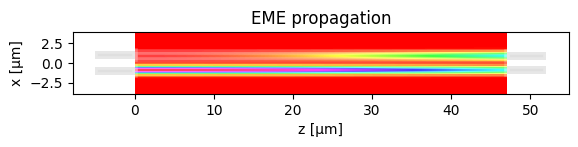

In [16]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



In [ ]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

Required Lpi for K = 0.01 with L = 10000 µm: 156817.09 µm


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

2026-03-12 14:56:59.562 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

2026-03-12 14:57:00.635 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_9c84fee5502c0325.npz.


...

2026-03-12 14:58:00.049 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_d6ce8b0f1417ee01.npz.


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

2026-03-12 14:58:01.343 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_618abcc6b7a773f6.npz.


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

2026-03-12 14:58:05.604 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_8e0bd02e52bb6fea.npz.


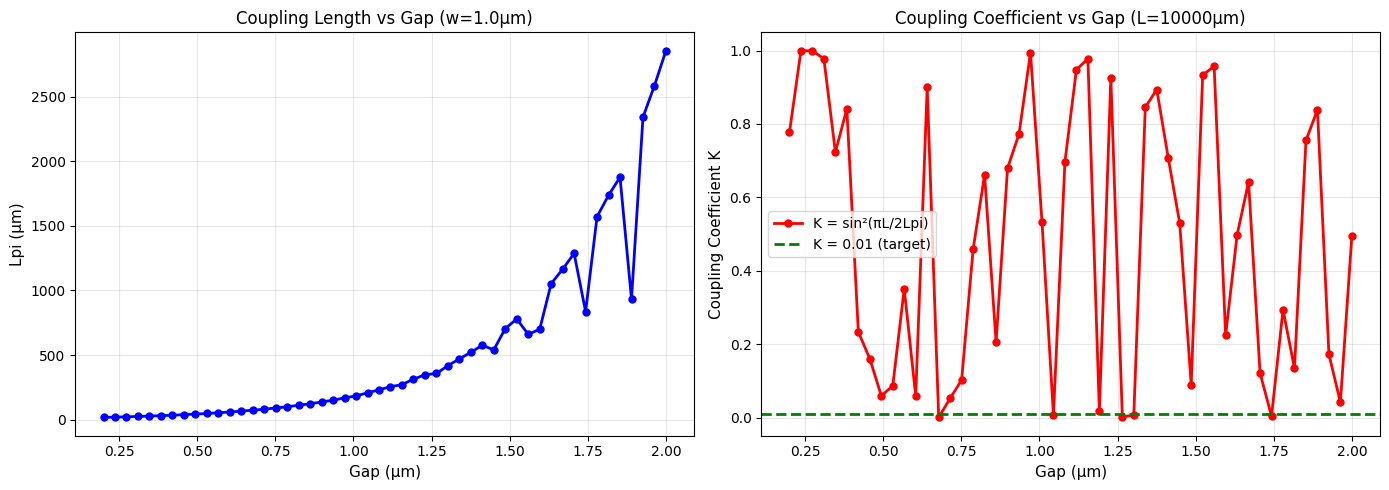


--- TE0 Mode (Deep-etched waveguide) ---
Minimum gap for K < 0.01: 0.678 µm
Coupling length Lpi: 73.52 µm
Coupling coefficient K: 0.000755


In [17]:
# LO.4: Parallel uncoupled waveguides
# Target: K < 0.01 with L = 10 mm for TE0 mode
# w = 1.0 µm, λ = 1.55 µm

lambda_c = 1.55  # µm
L_interaction = 10000  # µm (10 mm)
K_target = 0.01

# Calculate required Lpi for K = 0.01
# K = sin^2(pi*L/(2*Lpi)) = 0.01
# sin(pi*L/(2*Lpi)) = sqrt(0.01) = 0.1
# pi*L/(2*Lpi) = arcsin(0.1)
# Lpi = pi*L/(2*arcsin(0.1))
L_pi_required = np.pi * L_interaction / (2 * np.arcsin(np.sqrt(K_target)))
print(f"Required Lpi for K = {K_target} with L = {L_interaction} µm: {L_pi_required:.2f} µm")

# Sweep gaps to find the required one
gaps_nm = np.linspace(200, 2000, 50)
gaps_um = gaps_nm / 1000

L_pi_values = []
K_values = []

for gap in gaps_um:
    try:
        test_dc = gt.modes.WaveguideCoupler(
            wavelength=lambda_c,
            core_width=(1.0, 1.0),
            gap=gap,
            slab_thickness=0 * nm,
            core_material='sin',
            clad_material='sio2',
            core_thickness=300 * nm,
            num_modes=4,
            cache_path='.cache/',
            precision='double',
            max_grid_scaling=1.5,
            grid_resolution=20
        )
        test_neff = test_dc.n_eff
        L_pi_te = 0.5 * lambda_c / (test_neff[0].real - test_neff[1].real)
        K = np.sin(np.pi * L_interaction / (2 * L_pi_te))**2
        
        L_pi_values.append(L_pi_te)
        K_values.append(K)
        
        if K <= K_target and K >= K_target - 0.005:
            print(f"Gap = {gap:.3f} µm: Lpi = {L_pi_te:.2f} µm, K = {K:.6f}")
    except:
        pass

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(gaps_um, L_pi_values, 'b-o', linewidth=2, markersize=5)
ax1.set_xlabel('Gap (µm)', fontsize=11)
ax1.set_ylabel('Lpi (µm)', fontsize=11)
ax1.set_title('Coupling Length vs Gap (w=1.0µm)', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(gaps_um, K_values, 'r-o', linewidth=2, markersize=5, label='K = sin²(πL/2Lpi)')
ax2.axhline(y=K_target, color='g', linestyle='--', linewidth=2, label=f'K = {K_target} (target)')
ax2.set_xlabel('Gap (µm)', fontsize=11)
ax2.set_ylabel('Coupling Coefficient K', fontsize=11)
ax2.set_title(f'Coupling Coefficient vs Gap (L={L_interaction}µm)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Find minimum gap for K < 0.01
valid_indices = [i for i, k in enumerate(K_values) if k <= K_target]
if valid_indices:
    min_idx = valid_indices[0]
    min_gap = gaps_um[min_idx]
    min_K = K_values[min_idx]
    min_Lpi = L_pi_values[min_idx]
    print(f"\n--- TE0 Mode (Deep-etched waveguide) ---")
    print(f"Minimum gap for K < {K_target}: {min_gap:.3f} µm")
    print(f"Coupling length Lpi: {min_Lpi:.2f} µm")
    print(f"Coupling coefficient K: {min_K:.6f}")

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [18]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

2026-03-12 14:58:20.914 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [ ]:
mmi_body_waveguide.fraction_te

In [ ]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

In [ ]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

In [ ]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [19]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794418495


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [20]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255596  µm


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


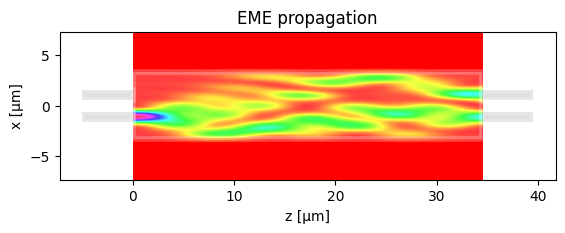

In [21]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/670 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9524
Total OUT power: 0.8900
Excess loss [dB] =  0.5062
------------------------
Power over OUTs:  ['0.4402', '0.4498']
Ratio over OUTs ['0.4946', '0.5054']


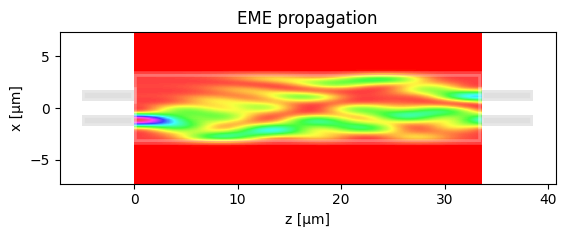

In [22]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [23]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.2 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255869  µm


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.2000
------------------------
Total power IN coupled 0.9646
Total OUT power: 0.9262
Excess loss [dB] =  0.3330
------------------------
Power over OUTs:  ['0.4682', '0.4580']
Ratio over OUTs ['0.5055', '0.4945']


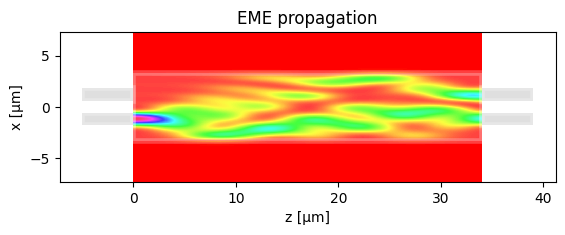

In [24]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

=== 1x4 MMI Coupler Design ===
MMI Body Width: 13.2 µm
Number of outputs: 4


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi = 263.95 µm

--- 1x4 MMI Coupler Configuration (Design 1) ---


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/3959 [00:00<?, ?it/s]

------- Pameters -------
MMI length 197.9627
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9480
Total OUT power: 0.2471
Excess loss [dB] =  6.0721
------------------------
Power over OUTs:  ['0.0039', '0.1196', '0.1196', '0.0039']
Ratio over OUTs ['0.0159', '0.4841', '0.4841', '0.0159']


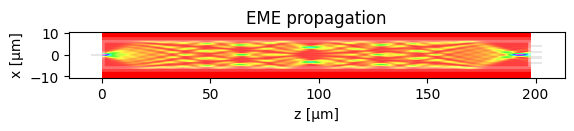

In [25]:
# LO.7: 1x4 Multimode Interference Coupler Design

# For a 1x4 coupler, we need to allocate 4 output waveguides
# Typical spacing for waveguides: 1.2 µm width + 0.6 µm gap between centers ≈ 1.8 µm per waveguide
# For 4 waveguides: at least 4*1.8 = 7.2 µm, but we'll use larger MMI body

mmi_Width_1x4 = 13.2  # Suitable width for 4 waveguides (1.2 µm each + gaps)

print("=== 1x4 MMI Coupler Design ===")
print(f"MMI Body Width: {mmi_Width_1x4} µm")
print(f"Number of outputs: 4")

m_1x4 = MMI_EME()
m_1x4.MMI_width = mmi_Width_1x4
m_1x4.MMI_num_modes = 25  # Higher number of modes for 1x4 coupler

# 1) Compute MMI body modes
m_1x4.find_all_modes()

# 2) Get L_pi
L_pi_1x4 = m_1x4.get_L_pi()
print(f"L_pi = {L_pi_1x4:.2f} µm")

# 3) Configure 1x4 MMI
# Based on design tables, for 1x4 coupler:
# - Length = (3/4) * Lpi for equal power distribution
m_1x4.n_IN = 1   # 1 input
m_1x4.n_OUT = 4  # 4 outputs

# Positions for 4 output waveguides (symmetrically distributed)
output_spacing = mmi_Width_1x4 / 5  # Space between waveguides
m_1x4.OUT_WVG_positions = np.array([-1.5, -0.5, 0.5, 1.5]) * output_spacing

# Input position (center)
m_1x4.IN_WVG_positions = np.array([0])

# MMI length for 1x4 coupler
m_1x4.L_MMI = (3/4) * L_pi_1x4

# Run propagation
print("\n--- 1x4 MMI Coupler Configuration (Design 1) ---")
m_1x4.propagation()


## Extra - Exercises

### E1. Directional coupler gap dependence

In [26]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

# STUDENT. Plot goes here


### E2. Directional coupler wavelength dependence

In [ ]:
wavelength = ... # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
L_pi_TE = ... # STUDENT code here

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Deep')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

2026-03-12 15:03:46.639 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_ab1aa1667946aeed.npz.


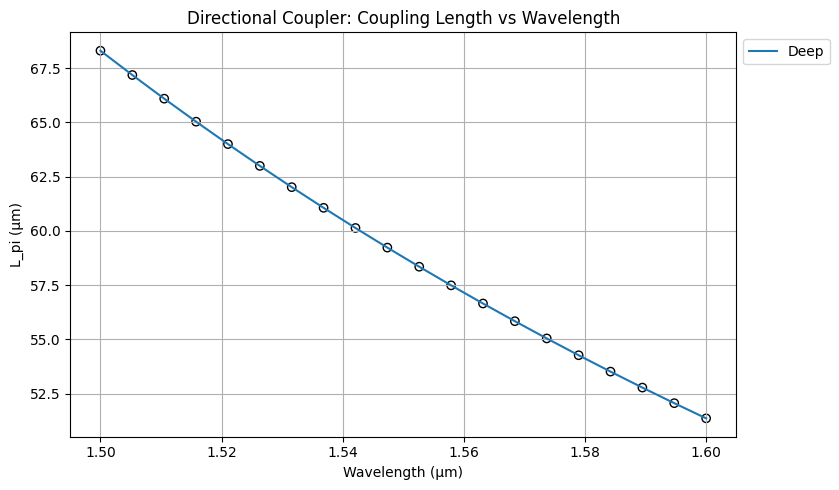

In [28]:
# E2: Directional coupler wavelength dependence

wavelength = np.linspace(1.5, 1.6, 20)  # 1.5 to 1.6 µm

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
# deep_neff shape is (20, 4) for wavelengths x modes
L_pi_TE = 0.5 * wavelength / (deep_neff[:, 0].real - deep_neff[:, 1].real)

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Deep')
plt.xlabel("Wavelength (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Directional Coupler: Coupling Length vs Wavelength")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

15:10:30 CET WARNING: Mode '13' appears to undergo a discontinuous change       
             between frequencies '190777018727272.72' and '191648146666666.66'  
             (overlap: '0.89').                                                 

             WARNING: Mode '14' appears to undergo a discontinuous change       
             between frequencies '190777018727272.72' and '191648146666666.66'  
             (overlap: '0.89').                                                 

15:10:31 CET WARNING: Mode field at frequency index 0, mode index 14 does not   
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 14 does not   
             decay at the plane boundaries.                                     

...

             WARNING: Mode field at frequency index 13, mode index 13 does not  
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 13, mode index 14 does not  
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 14, mode index 13 does not  
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 14, mode index 14 does not  
             decay at the plane boundaries.                                     

2026-03-12 15:10:34.196 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9a84ec86ddf79b0a.npz.


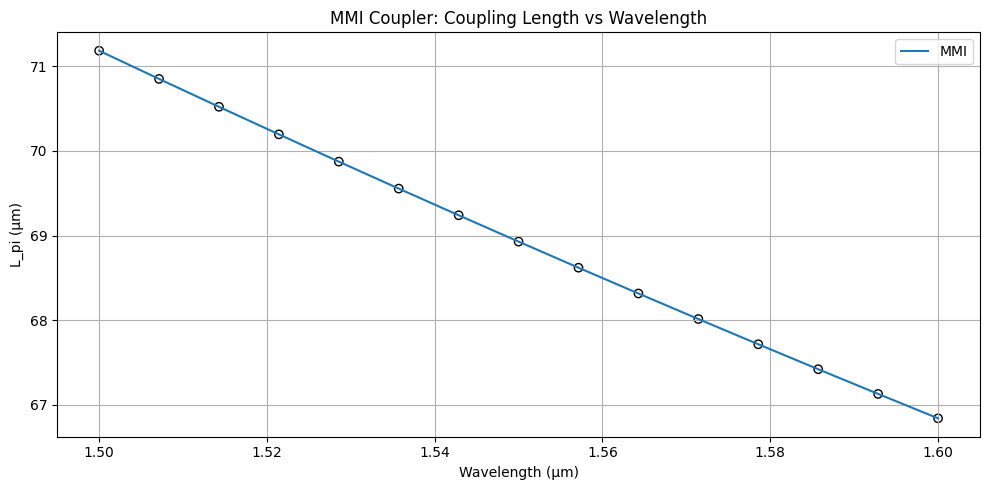

In [29]:
# E3: MMI coupler wavelength dependence

mmi_body_w = 6.6 
lambda_c = np.linspace(1.5, 1.6, 15)

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[:, 0].real - mmi_body_waveguide.n_eff[:, 1].real

L_pi = 0.5 * lambda_c / d_n_eff

plt.figure(figsize=(10, 5))
plt.scatter(lambda_c, L_pi, edgecolors='k', facecolors='none')
plt.plot(lambda_c, L_pi, label='MMI')
plt.xlabel("Wavelength (µm)")
plt.ylabel("L_pi (µm)")
plt.title("MMI Coupler: Coupling Length vs Wavelength")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### E4. MMI coupler body width dependence

In [30]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

15:12:53 CET WARNING: Mode field at frequency index 0, mode index 14 does not   
             decay at the plane boundaries.                                     

2026-03-12 15:12:53.397 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_cc174b674ffff0ec.npz.


# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points